Curvature from Hessian-vector products
======================================

**When to use:** you need second-order information about the loss: the curvature that limits a gradient step, how
well conditioned a fit is, or Newton steps on a few parameters.

**What you will see:** an affine registration of 10,000 points with 6 parameters; its 6 x 6 Hessian from 6
Hessian-vector products, each a double backward through the solver; the step size it gives gradient descent; when
Newton steps converge; what each approach costs; and what the Hessian-vector product supports.

Source: [plot_hvp_newton.py](plot_hvp_newton.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/advanced/plot_hvp_newton.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/advanced/plot_hvp_newton.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (ARROW, SOURCE, TARGET, THIRD, dense_size, images_dir, require_cuda, save, table,  # noqa: E402
                       timed)

device = require_cuda()
torch.manual_seed(0)


def crescent(n):
    """n points uniform in a disk minus an overlapping smaller disk."""
    points = torch.empty(0, 2, device=device)
    while len(points) < n:
        r = 0.6 * torch.rand(4 * n, device=device).sqrt()
        angle = 2 * math.pi * torch.rand(4 * n, device=device)
        candidates = torch.stack([r * angle.cos(), r * angle.sin()], dim=1)
        keep = (candidates - torch.tensor([0.25, 0.0], device=device)).norm(dim=1) > 0.45
        points = torch.cat([points, candidates[keep]])
    return points[:n]

An affine registration
----------------------
Find A and b such that the cloud z A' + b matches y, a fresh sample of the same shape moved by an unknown affine
map: six parameters, 10,000 points on each side. The loss is the entropic OT cost, because the Hessian-vector
product supports ``debias=False`` only. It differentiates the solver's optimality conditions, so it assumes
converged potentials: the careful solve below uses FP32 and a slower schedule (``scaling=0.95``), as for plans.

In [ ]:
n = 10_000
A_true = torch.tensor([[1.2, 0.4], [-0.3, 0.8]], device=device)
b_true = torch.tensor([0.5, -0.2], device=device)
z = crescent(n)
y = crescent(n) @ A_true.T + b_true
print(dense_size(n, n))
careful = SamplesLoss(blur=0.05, half_cost=True, debias=False, backend="symmetric", scaling=0.95, allow_tf32=False,
                      autotune=False)
default = SamplesLoss(blur=0.05, half_cost=True, debias=False, backend="symmetric", autotune=False)
theta0 = torch.tensor([1.0, 0.0, 0.0, 1.0, 0.0, 0.0], device=device)


def loss_of(loss, theta):
    return loss(z @ theta[:4].reshape(2, 2).T + theta[4:], y)


def gradient(loss, theta):
    theta = theta.clone().requires_grad_(True)
    value = loss_of(loss, theta)
    grad, = torch.autograd.grad(value, theta)
    return value.item(), grad


def hessian(loss, theta):
    """The 6 x 6 Hessian, one double backward per gradient component, stacked as rows."""
    theta = theta.clone().requires_grad_(True)
    grad, = torch.autograd.grad(loss_of(loss, theta), theta, create_graph=True)
    return torch.stack([torch.autograd.grad(grad[k], theta, retain_graph=True)[0] for k in range(6)])


def eigenvalues(H):
    return torch.linalg.eigvalsh((H + H.T) / 2)


def show(values):
    return " ".join(f"{e:.3g}" for e in values.tolist())

Curvature at the start
----------------------
On a quadratic with positive curvature, gradient descent is stable for steps below 2 / lambda_max, where lambda_max
is the largest eigenvalue of the Hessian. The smallest eigenvalue is close to zero at the start, and it moves with
the accuracy of the solve (compare the default schedule): a Newton step, which divides the gradient by the
curvature, would be large and its direction unreliable.

In [ ]:
H = timed("Hessian from 6 Hessian-vector products", lambda: hessian(careful, theta0))
lambda_max = eigenvalues(H).max().item()
print(f"eigenvalues at the start: {show(eigenvalues(H))}")
print(f"the same with the default schedule: {show(eigenvalues(hessian(default, theta0)))}")

Gradient descent and Newton's method
------------------------------------
Gradient descent with the step 1 / lambda_max; the same with a step above 2 / lambda_max, which diverges; and ten
gradient steps followed by Newton steps theta <- theta - H^-1 grad. After ten steps the smallest eigenvalue is
well away from zero, and Newton's method converges in a few steps, each with a fresh Hessian (six Hessian-vector
products). The last run repeats it with the default schedule and TF32 precision. Every run is scored with the
careful solve; the plot clips the smallest loss gaps to keep the optimization progress visible. A is not recovered
exactly, because the loss is not debiased and z and y are different samples.

In [ ]:
def gradient_step(scale):
    return lambda loss, theta: theta - scale * gradient(loss, theta)[1] / lambda_max


def newton_step(loss, theta):
    return theta - torch.linalg.solve(hessian(loss, theta), gradient(loss, theta)[1])


def run(loss, steps):
    """Takes the steps, a list of (step, count), with the gradients and Hessians of ``loss``."""
    thetas, seconds = [theta0], [0.0]
    torch.cuda.synchronize()
    start = time.perf_counter()
    for step, count in steps:
        for _ in range(count):
            thetas.append(step(loss, thetas[-1]))
            torch.cuda.synchronize()
            seconds.append(time.perf_counter() - start)
    return thetas, seconds


switch = 10
hybrid = [(gradient_step(1.0), switch), (newton_step, 4)]
runs = {
    "gradient descent, step 1/lambda_max": run(careful, [(gradient_step(1.0), 300)]),
    "gradient descent, step 2.5/lambda_max": run(careful, [(gradient_step(2.5), 20)]),
    f"{switch} gradient steps, then Newton": run(careful, hybrid),
    "the same, default schedule": run(default, hybrid),
}
at_switch = runs[f"{switch} gradient steps, then Newton"][0][switch]
print(f"eigenvalues after {switch} gradient steps: {show(eigenvalues(hessian(careful, at_switch)))}")
scores = {name: [loss_of(careful, theta).item() for theta in thetas] for name, (thetas, _) in runs.items()}
best = min(min(values) for values in scores.values())
rows = []
for name, (thetas, seconds) in runs.items():
    gap = scores[name][-1] - best
    error = (thetas[-1][:4] - A_true.flatten()).norm().item()
    rows.append([name, str(len(thetas) - 1), f"{seconds[-1]:.1f} s", f"{gap:.1e}", f"{error:.3f}"])
    print(f"{name}: {len(thetas) - 1} steps in {seconds[-1]:.1f} s, loss - best {gap:.1e}, error of A {error:.3f}")

What the Hessian-vector product supports
----------------------------------------
Products are taken with respect to x (here through A and b) for the raw OT cost, with y and the weights fixed,
``debias=False`` and no label cost. Each product solves a linear system by conjugate gradients
(``hvp_max_cg_iter``, ``hvp_cg_rtol``, ``hvp_tau2``); when they stop before their tolerance a warning says so, as
here with a deliberately small iteration budget.

In [ ]:
short = SamplesLoss(blur=0.05, half_cost=True, debias=False, backend="symmetric", autotune=False, hvp_max_cg_iter=3)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    theta = theta0.clone().requires_grad_(True)
    grad, = torch.autograd.grad(loss_of(short, theta), theta, create_graph=True)
    torch.autograd.grad(grad[0], theta)
print("warnings:", [str(w.message)[:100] for w in caught if "conjugate" in str(w.message)] or "none")

Figure
------

In [ ]:
fig, (ax_curve, ax_table) = plt.subplots(1, 2, figsize=(13.0, 4.2), gridspec_kw=dict(width_ratios=[1, 1.4]))
for (name, (_, seconds)), color in zip(runs.items(), (TARGET, SOURCE, ARROW, THIRD)):
    gaps = [max(value - best, 1e-12) for value in scores[name]]
    ax_curve.semilogy(seconds, gaps, ".-", color=color, label=name, markersize=3)
ax_curve.set_xlabel(f"seconds ({torch.cuda.get_device_name()})")
ax_curve.set_ylabel("loss - best loss (careful solve)")
ax_curve.set_ylim(1e-8, 10)
ax_curve.legend(frameon=False, fontsize=8)
table(ax_table, ["method", "steps", "time", "loss - best", "error of A"], rows, fontsize=9)
fig.tight_layout()
save(fig, images_dir(__file__), "hvp_newton")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/advanced/images/hvp_newton.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

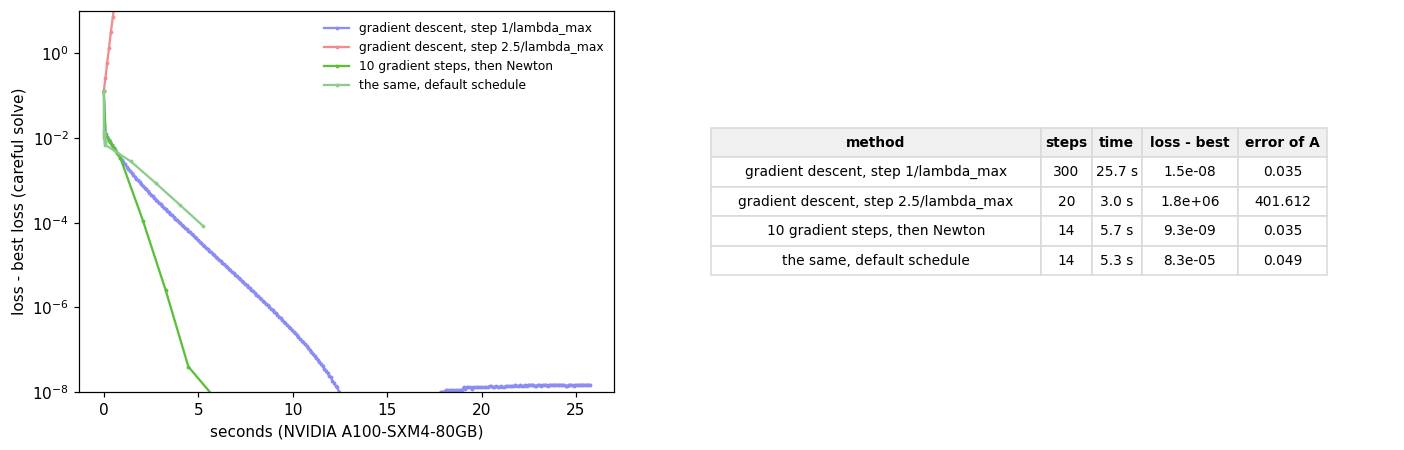